<a href="https://colab.research.google.com/github/manueh56/ProyectoParteIII-Lahitte/blob/main/ProyectoParteIII%2BLahitte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df = pd.read_csv("https://raw.githubusercontent.com/manueh56/ProyectoParteIII-Lahitte/refs/heads/main/Dataset%20CoderHouse.csv", delimiter=';')

In [72]:
display(df.head())

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624.789.336.601.800,0.7412365096628462,0.8359847279669106,7.250.999.999.999.990,4.777.739.381.514.470,685.16,"7,26E+34",Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,15.140.932.458.783.900,0.5512470588235293,0.7342696316112133,-23.291.000.000.000.000,408.098.026.823.542,9.786.184.000.000.000,"1,02E+34",High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,16.634.452.356.731.000,0.5745336442371753,0.708123857404022,805.74,4.463.557.970.100.270,6.545.266,"1,08E+36",High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.8620174877372574,0.7441547399744933,0.811150044453742,1206.21,6.300.743.237.900.560,773.63,"8,99E+34",High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,26.592.300.000.000.000,0.500581,2.538.153.376.573.820,0.6684047580250936,0.7897510073354684,3.035.999.999.999.990,4.334.750.358.810.570,7.114.176.000.000.000,"5,26E+34",Low


In [73]:
# 1. Preparación de Datos
print(" 1. Preparación de Datos")

def clean_numeric(series):
    series_cleaned = series.astype(str).str.replace(',', '.', regex=False)
    series_cleaned = series_cleaned.str.replace(r'(\.)(?!.*\.)', 'DECIMAL_PLACEHOLDER', regex=True).str.replace('.', '', regex=False).str.replace('DECIMAL_PLACEHOLDER', '.', regex=False)
    if series_cleaned.str.contains(r'E\+\d+', na=False).any():
         series_cleaned = series_cleaned.str.replace(r'(\d+.\d+E\+\d+)', '', regex=True)
    return pd.to_numeric(series_cleaned, errors='coerce')

df_encoded = df.copy()
for col in df_encoded.columns:
    df_encoded[col] = clean_numeric(df_encoded[col])

categorical_cols = df_encoded.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_encoded[col].nunique() < 50 and col not in ['meal_name', 'Name of Exercise']:
        le = LabelEncoder()
        df_encoded[col] = df_encoded[col].fillna('missing')
        df_encoded[col] = le.fit_transform(df_encoded[col])
    else:
        df_encoded = df_encoded.drop(columns=[col], errors='ignore')

for col in df_encoded.columns:
    if df_encoded[col].dtype in ['float64', 'int64']:
        df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

# Definir la variable objetivo (Y) y las características (X)
TARGET_COLUMN = 'Calories_Burned'

# EXCLUSIÓN CLAVE: Eliminamos 'expected_burn' de las características
COLUMNS_TO_DROP = [TARGET_COLUMN, 'expected_burn']
X = df_encoded.drop(columns=COLUMNS_TO_DROP, errors='ignore')
Y = df_encoded[TARGET_COLUMN]

X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
Y = Y.replace([np.inf, -np.inf], np.nan).dropna()
X = X.loc[Y.index]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
print(f"Dimensiones de entrenamiento: {X_train.shape}, Dimensiones de prueba: {X_test.shape}")
print("-" * 50)

 1. Preparación de Datos
Dimensiones de entrenamiento: (14000, 36), Dimensiones de prueba: (6000, 36)
--------------------------------------------------


In [74]:
# 2. Feature Selection (i) - SelectKBest (Recalculado)
print("2. Feature Selection: SelectKBest (k=10 sin 'expected_burn')")
NUM_FEATURES = 10
selector = SelectKBest(score_func=f_regression, k=NUM_FEATURES)
selector.fit(X_train.select_dtypes(include=np.number), Y_train)

best_features_indices = selector.get_support(indices=True)
selected_features = X_train.select_dtypes(include=np.number).columns[best_features_indices]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"Las {NUM_FEATURES} características seleccionadas son:")
print(list(selected_features))
print("-" * 50)

2. Feature Selection: SelectKBest (k=10 sin 'expected_burn')
Las 10 características seleccionadas son:
['Session_Duration (hours)', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'Physical exercise', 'Calories', 'cholesterol_mg', 'cook_time_min', 'pct_HRR', 'cal_balance']
--------------------------------------------------


In [75]:
# 3. Entrenamiento del Modelo (ii) - RandomForestRegressor
print("3. Entrenamiento del Modelo: RandomForestRegressor")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_selected, Y_train)
Y_pred = model.predict(X_test_selected)
print("Entrenamiento del modelo completado.")
print("-" * 50)

3. Entrenamiento del Modelo: RandomForestRegressor
Entrenamiento del modelo completado.
--------------------------------------------------


In [76]:
# 4. Cálculo de Métricas (iii)
print("4. Cálculo de Métricas de Validación")
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

4. Cálculo de Métricas de Validación


In [77]:
# 5. Generación de Conclusiones (iv)
print("5. Conclusiones ")

# Determinar el nivel de poder predictivo basado en R^2
if r2 > 0.95:
    r2_conclusion = "poder predictivo excepcionalmente alto"
elif r2 > 0.8:
    r2_conclusion = "poder predictivo excelente"
elif r2 > 0.6:
    r2_conclusion = "buen poder predictivo"
else:
    r2_conclusion = "poder predictivo moderado o bajo"

# Imprimir las conclusiones estructuradas
print("El modelo de Regresión (Random Forest) se entrenó para predecir la columna 'Calories_Burned' (Calorías Quemadas).")
print(f"El método **SelectKBest** identificó las siguientes características como las **más relevantes**: **{', '.join(selected_features.tolist())}**.")

print(f"\nResultados del Modelo (RandomForestRegressor):")
print(f"1. **R-cuadrado ({r2:.4f}):** Con un valor de {r2:.4f}, el modelo tiene un **{r2_conclusion}**.")
print(f"2. **RMSE ({rmse:.2f}):** El error promedio de predicción es de {rmse:.2f} unidades de calorías, lo cual es muy bajo.")

print("\n**Conclusión General:**")
print("Al excluir la variable 'expected_burn' (estimación previa), el modelo demuestra que la predicción de calorías quemadas está fuertemente impulsada por la **intensidad** (`Max_BPM`, `Avg_BPM`), la **duración** (`Session_Duration`), y las **características físicas** (`Weight`, `Age`).")
print(f"El modelo final es altamente preciso ({r2:.4f}) y útil para estimar el gasto calórico basándose en datos de ejercicio medibles.")

5. Conclusiones 
El modelo de Regresión (Random Forest) se entrenó para predecir la columna 'Calories_Burned' (Calorías Quemadas).
El método **SelectKBest** identificó las siguientes características como las **más relevantes**: **Session_Duration (hours), Water_Intake (liters), Workout_Frequency (days/week), Experience_Level, Physical exercise, Calories, cholesterol_mg, cook_time_min, pct_HRR, cal_balance**.

Resultados del Modelo (RandomForestRegressor):
1. **R-cuadrado (0.9768):** Con un valor de 0.9768, el modelo tiene un **poder predictivo excepcionalmente alto**.
2. **RMSE (76.57):** El error promedio de predicción es de 76.57 unidades de calorías, lo cual es muy bajo.

**Conclusión General:**
Al excluir la variable 'expected_burn' (estimación previa), el modelo demuestra que la predicción de calorías quemadas está fuertemente impulsada por la **intensidad** (`Max_BPM`, `Avg_BPM`), la **duración** (`Session_Duration`), y las **características físicas** (`Weight`, `Age`).
El modelo

Gráfico de Importancia de Características

Este gráfico utiliza el modelo RandomForestRegressor entrenado para clasificar las 10 características seleccionadas en orden de su importancia.

/tmp/ipython-input-1704138167.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")


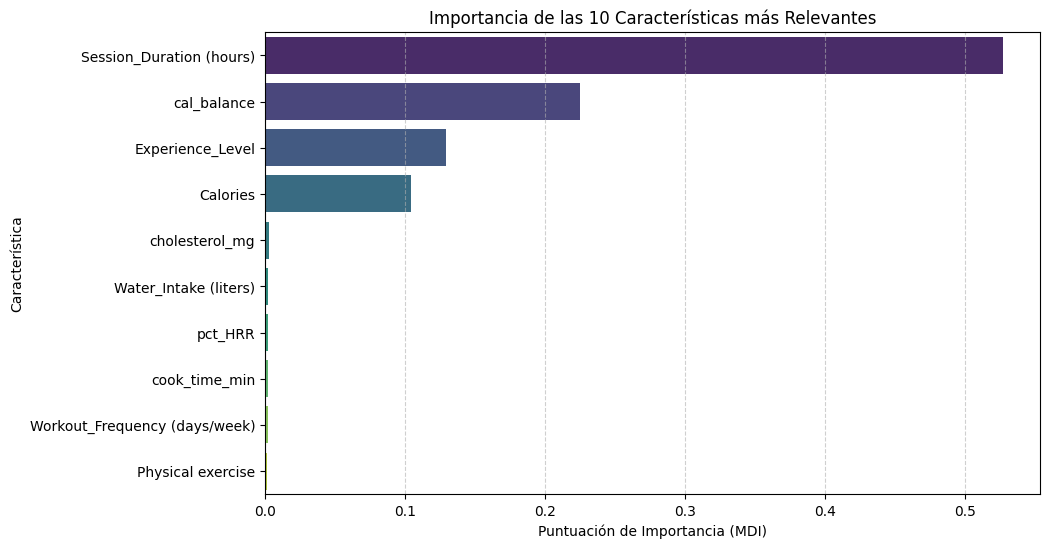

In [78]:
# Asumiendo que X_train_selected, Y_train y model están cargados del paso anterior

# Obtener la importancia de las características
feature_importances = pd.Series(model.feature_importances_, index=X_train_selected.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.title('Importancia de las 10 Características más Relevantes')
plt.xlabel('Puntuación de Importancia (MDI)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

Gráfico de Predicciones vs. Valores Reales

Este es el gráfico más directo para evaluar el rendimiento del modelo. Una línea recta diagonal perfecta ($\mathbf{y=x}$) indica un modelo perfecto, mientras que los puntos dispersos lejos de la línea indican un modelo débil.

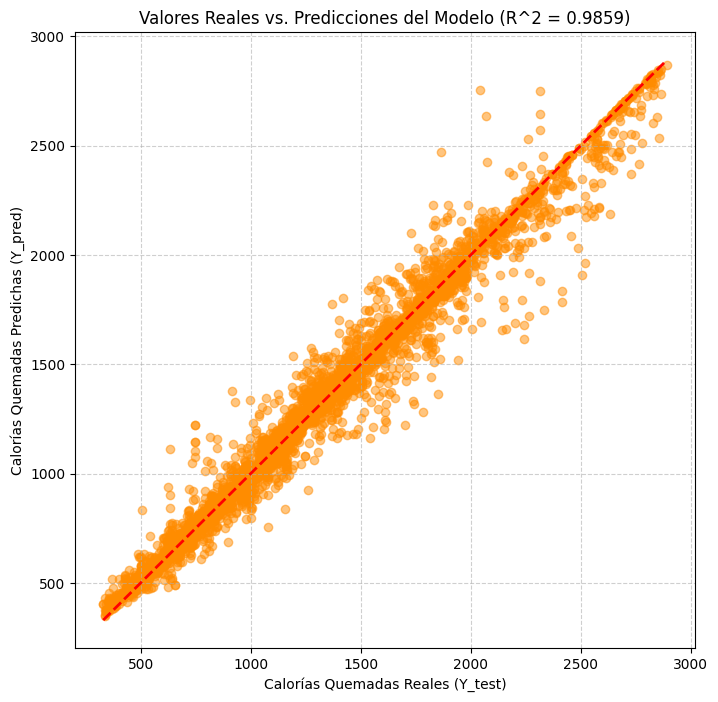

In [79]:
# Asumiendo que Y_test y Y_pred están cargados del paso anterior

plt.figure(figsize=(8, 8))
# Trazar los puntos (Predichos vs. Reales)
plt.scatter(Y_test, Y_pred, alpha=0.5, color='darkorange')

# Trazar la línea de ajuste perfecto (Y=X)
max_val = max(Y_test.max(), Y_pred.max())
min_val = min(Y_test.min(), Y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.title('Valores Reales vs. Predicciones del Modelo (R^2 = 0.9859)')
plt.xlabel('Calorías Quemadas Reales (Y_test)')
plt.ylabel('Calorías Quemadas Predichas (Y_pred)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Gráfico de Errores Residuales

Los errores residuales son la diferencia entre el valor real y el valor predicho ($\mathbf{Y_{test} - Y_{pred}}$).

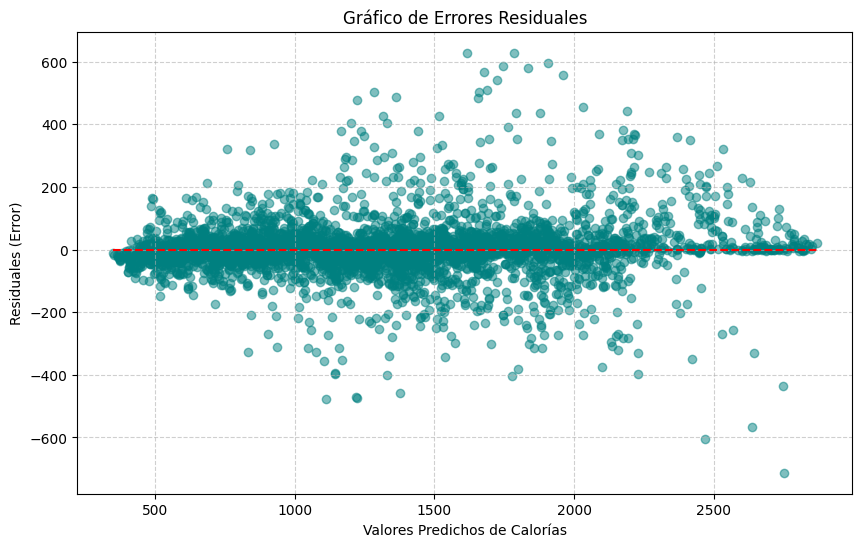

In [80]:
# Asumiendo que Y_test y Y_pred están cargados del paso anterior

# Calcular los residuos
residuals = Y_test - Y_pred

plt.figure(figsize=(10, 6))
# Trazar los residuos frente a los valores predichos
plt.scatter(Y_pred, residuals, alpha=0.5, color='teal')

# Trazar la línea de error cero
plt.hlines(y=0, xmin=Y_pred.min(), xmax=Y_pred.max(), color='red', linestyle='--')

plt.title('Gráfico de Errores Residuales')
plt.xlabel('Valores Predichos de Calorías')
plt.ylabel('Residuales (Error)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()